# 01 Market Overview (Hypothesis)
## Which beauty tier is growing fastest? (2022–present)

This notebook analyses revenue trends across luxury, prestige, masstige, and mass 
beauty segments using publicly available annual report data from nine entities 
spanning six companies across Western Europe, North America, and Japan.

**Companies & segments covered:**
LVMH Perfumes & Cosmetics, Estée Lauder Group, L'Oréal Luxe, 
L'Oréal Dermatological Beauty, L'Oréal Consumer Products, 
Shiseido Group, Kosé Group, Unilever Beauty & Wellbeing, Kao Cosmetics Business

**Period:** Fiscal years 2022–2025  
**Currency:** USD (converted using annual average FX rates)  
**Data source:** Company annual reports and investor relations disclosures

**Hypothesis:** Masstige is outperforming both luxury and mass segments, driven 
by an aspirational but value-conscious post-COVID consumer.


**Methodology: Company & Tier Classification**


Tier Definitions

Tiers are defined by **average unit price and distribution channel**, 
not company identity:

| Tier | Price Point | Distribution |
|---|---|---|
| Luxury | >€50 avg unit price | Selective — own boutiques, dept stores, Sephora |
| Prestige | €20–50 | Selective to broad — Sephora, Ulta, dept stores |
| Masstige | €10–20 | Broad — drugstore, pharmacy, mass retail |
| Mass | <€10 | Mass retail — supermarket, drugstore, convenience |

Company & Segment Mapping

| Entity | Tier | Rationale |
|---|---|---|
| LVMH Perfumes & Cosmetics | Luxury | Dior Beauty, Guerlain, Givenchy |
| Estée Lauder (group) | Luxury/Prestige | Estée Lauder, MAC, Clinique, La Mer |
| L'Oréal Luxe | Prestige | Lancôme, YSL Beauty, Armani Beauty |
| L'Oréal Dermatological Beauty | Masstige | CeraVe, La Roche-Posay, SkinCeuticals |
| Shiseido (group) | Prestige/Masstige | Clé de Peau, NARS, Shiseido brand |
| Kosé (group) | Prestige/Masstige | Decorté, Kosé, Fasio |
| L'Oréal Consumer Products | Mass | L'Oréal Paris, Maybelline, Garnier |
| Unilever Beauty & Wellbeing | Mass | Dove, TRESemmé, Sunsilk |
| Kao Cosmetics | Mass | Bioré, Curél, KATE |

Acknowledged Limitations
1. **Segment-level proxies**: Revenue figures are reported at division/segment 
   level. Sub-segment price tier splits are not disclosed in public financials.
2. **Mixed-tier segments**: Estée Lauder, Shiseido, Kao, and Kosé contain brands 
   spanning multiple price tiers. Classified by dominant positioning.
3. **Currency**: L'Oréal and LVMH report in EUR; Shiseido, Kosé, and Kao in JPY; 
   Estée Lauder and Unilever in USD. All converted to USD for comparison 
   using annual average FX rates.
4. **No pure-play mass Western benchmark**

Geographic Coverage

Western Europe (L'Oréal, LVMH), North America (Estée Lauder), 
Japan (Shiseido, Kosé, Kao), Global mass (Unilever)

### Library Imports

In [7]:
# ── Setup ─────────────────────────────────────────────────
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.helpers import *

set_style()
print("Setup complete ✓")

Setup complete ✓


### Data Acquisition

Three methods used — chosen based on each source's data structure:

- **L'Oréal** → BeautifulSoup (HTML scrape) — figures published directly on IR web pages
- **LVMH / Shiseido / Kao** → pdfplumber (PDF extraction) — figures published in structured annual report PDFs

All figures reflect beauty/cosmetics segment revenue only, in EUR millions (LVMH/L'Oréal) or USD billions (Shiseido/Kao, converted).

*1. L'Oréal BeautifulSoup HTML scrape*

In [8]:
import re
import requests
from bs4 import BeautifulSoup

# ── Reusable L'Oréal scraper ───────────────────────────────
def scrape_loreal_results(url, year):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    
    if response.status_code != 200:
        print(f"Failed to fetch {year}: status {response.status_code}")
        return None
    
    soup = BeautifulSoup(response.text, "html.parser")
    tables = soup.find_all("table")
    
    target_table = None
    for table in tables:
        first_cells = [c.get_text(strip=True) for c in table.find_all(["td","th"])]
        if "By Division" in first_cells:
            target_table = table
            break
    
    if not target_table:
        print(f"{year}: could not find division table")
        return None

    # ── Normalise historical name changes ─────────────────
    name_map = {
        "Active Cosmetics": "Dermatological Beauty"
    }

    divisions = [
        "Professional Products", 
        "Consumer Products", 
        "L\u2019Oréal Luxe",
        "Dermatological Beauty"
    ]
    
    results = {"Year": year}
    for row in target_table.find_all("tr"):
        cells = [c.get_text(strip=True) for c in row.find_all(["td","th"])]
        if not cells:
            continue
        clean_name = re.sub(r'\[\d+\]', '', cells[0]).strip()
        clean_name = name_map.get(clean_name, clean_name)  # apply normalisation
        if clean_name in divisions:
            results[clean_name] = float(cells[4].replace(",", ""))
    
    print(f"{year} scraped ✓ — {len(results)-1} divisions found")
    return results

In [9]:
# ── Scrape 2022–2025 ───────────────────────────────────────
urls = {
    2022: "https://www.loreal-finance.com/eng/press-release/2022-annual-results",
    2023: "https://www.loreal-finance.com/eng/news-release/2023-annual-results",
    2024: "https://www.loreal-finance.com/eng/press-release/2024-annual-results",
    2025: "https://www.loreal-finance.com/eng/press-release/2025-annual-results"
}

loreal_data = [scrape_loreal_results(url, year) for year, url in urls.items()]
print(loreal_data)


2022 scraped ✓ — 4 divisions found
2023 scraped ✓ — 4 divisions found
2024 scraped ✓ — 4 divisions found
2025 scraped ✓ — 4 divisions found
[{'Year': 2022, 'Professional Products': 4476.8, 'Consumer Products': 14021.3, 'L’Oréal Luxe': 14638.1, 'Dermatological Beauty': 5124.5}, {'Year': 2023, 'Professional Products': 4653.9, 'Consumer Products': 15172.7, 'L’Oréal Luxe': 14924.0, 'Dermatological Beauty': 6432.0}, {'Year': 2024, 'Professional Products': 4886.2, 'Consumer Products': 15982.4, 'L’Oréal Luxe': 15591.1, 'Dermatological Beauty': 7027.1}, {'Year': 2025, 'Professional Products': 5163.0, 'Consumer Products': 16089.7, 'L’Oréal Luxe': 15595.1, 'Dermatological Beauty': 7204.1}]


*Scraped data saved to folder*

In [10]:
# ── Convert to DataFrame ──────────────────────────────────
df_loreal = pd.DataFrame([r for r in loreal_data if r is not None])
print(df_loreal)

   Year  Professional Products  Consumer Products  L’Oréal Luxe  \
0  2022                 4476.8            14021.3       14638.1   
1  2023                 4653.9            15172.7       14924.0   
2  2024                 4886.2            15982.4       15591.1   
3  2025                 5163.0            16089.7       15595.1   

   Dermatological Beauty  
0                 5124.5  
1                 6432.0  
2                 7027.1  
3                 7204.1  


In [11]:
df_loreal.to_csv("../data/processed/loreal_revenue.csv", index=False)
print("Saved ✓")

import pandas as pd

df_loreal = pd.read_csv("../data/processed/loreal_revenue.csv")

# Keep only the three divisions in our basket
df_loreal = df_loreal[["Year", "Consumer Products", "L\u2019Oréal Luxe", "Dermatological Beauty"]]

df_loreal = df_loreal.rename(columns={
    "Consumer Products": "Consumer Products (EUR M)",
    "L\u2019Oréal Luxe": "L'Oréal Luxe (EUR M)",
    "Dermatological Beauty": "Dermatological Beauty (EUR M)"
})

df_loreal.to_csv("../data/processed/loreal_revenue.csv", index=False)
print("Saved ✓")
print(df_loreal)

Saved ✓
Saved ✓
   Year  Consumer Products (EUR M)  L'Oréal Luxe (EUR M)  \
0  2022                    14021.3               14638.1   
1  2023                    15172.7               14924.0   
2  2024                    15982.4               15591.1   
3  2025                    16089.7               15595.1   

   Dermatological Beauty (EUR M)  
0                         5124.5  
1                         6432.0  
2                         7027.1  
3                         7204.1  


📝 Maintenance Notes — L'Oréal Scraper

**To update for a new year:**
- Add new year URL to the `urls` dict
- Format: `YYYY: "https://www.loreal-finance.com/eng/press-release/YYYY-annual-results"`
- Note: 2023 used `/news-release/` not `/press-release/` — check URL format if scrape fails

**If a division is missing:**
- Run the diagnostic cell to print exact division names from the target page
- L'Oréal has rebranded divisions before (e.g. "Active Cosmetics" → "Dermatological Beauty" in 2023)
- Add any new name mappings to the `name_map` dictionary in the function

**If scrape returns 0 divisions:**
- Page structure may have changed — check which table index contains "By Division"
- Function now searches dynamically so should be resilient, but verify if L'Oréal redesigns their IR page

**If status 404:**
- URL format may have changed — check loreal-finance.com directly for the correct press release URL

**Known issues resolved:**
- Curly apostrophe in `L'Oréal Luxe` — handled via unicode `\u2019`
- Footnote tags like `[4]` — stripped via `re.sub`
- "Active Cosmetics" rename — handled via `name_map`

*2. LVMH pdfplumber data extraction*

In [12]:
#Libraries import

import pdfplumber
import glob

# ── Scan folder for all LVMH PDFs ─────────────────────────
pdf_files = glob.glob("../data/raw/lvmh/*.pdf")
print("PDFs found:", pdf_files)

# ── Explore first PDF structure ────────────────────────────
with pdfplumber.open(pdf_files[0]) as pdf:
    print(f"Total pages: {len(pdf.pages)}")
    
    # Search for the page containing Perfumes & Cosmetics
    for i, page in enumerate(pdf.pages):
        text = page.extract_text()
        if text and "Perfumes" in text:
            print(f"\nFound 'Perfumes' on page {i+1}")
            print(text[:1000])
            break

PDFs found: ['../data/raw/lvmh\\lvmh_2022.pdf', '../data/raw/lvmh\\lvmh_2023.pdf', '../data/raw/lvmh\\lvmh_2024.pdf', '../data/raw/lvmh\\lvmh_2025.pdf']
Total pages: 70

Found 'Perfumes' on page 4
FINANCIAL HIGHLIGHTS
Revenue Change in revenue by business group 2022 2021 2022/2021 Change 2020
(EUR millions) (EUR millions and percentage)
Published Organic (a)
79,184
Wines and Spirits 7,099 5,974 19% 11% 4,755
64,215 Fashion and Leather Goods 38,648 30,896 25% 20% 21,207
Perfumes and Cosmetics 7,722 6,608 17% 10% 5,248
44,651 Watches and Jewelry 10,581 8,964 18% 12% 3,356
Selective Retailing 14,852 11,754 26% 17% 10,155
Other activities and eliminations 281 19 - - (70)
Total 79,184 64,215 23% 17% 44,651
(a) On a constant consolidation scope and currency basis. The net impact of exchange rate fluctuations on Group revenue was 6%
and the net impact of changes in the scope of consolidation was negligible. The principles used to determine the net impact
2020 2021 2022 of exchange rate fluctu

In [13]:
import pdfplumber
import re
import glob
import pandas as pd

def extract_lvmh_data(pdf_folder):
    pdf_files = sorted(glob.glob(f"{pdf_folder}/*.pdf"))
    all_data = {}

    for pdf_path in pdf_files:
        fname_match = re.search(r'lvmh_(\d{4})\.pdf', pdf_path)
        if not fname_match:
            continue
        report_year = int(fname_match.group(1))

        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if not text or "Perfumes" not in text:
                    continue

                for line in text.split("\n"):
                    if "Perfumes" in line:
                        # Filter out group-level totals (e.g. 64,215) — P&C never exceeds 15,000
                        numbers = [
                            n for n in re.findall(r'\b\d{1,4},\d{3}\b', line)
                            if int(n.replace(',', '')) < 15000
                        ]
                        if len(numbers) >= 2:
                            years = [report_year - i for i in range(len(numbers))]
                            for year, num in zip(years, numbers):
                                if year not in all_data and 2022 <= year <= 2025:
                                    all_data[year] = float(num.replace(',', ''))
                                    print(f"FY{year}: €{num}M ✓  (from {pdf_path.split('/')[-1]})")
                            break
                break

    df = pd.DataFrame([
        {"Year": year, "Net Sales (EUR M)": sales}
        for year, sales in sorted(all_data.items())
    ])
    return df

df_lvmh = extract_lvmh_data("../data/raw/lvmh")
print("\n", df_lvmh)


FY2022: €7,722M ✓  (from lvmh\lvmh_2022.pdf)
FY2023: €8,271M ✓  (from lvmh\lvmh_2023.pdf)
FY2024: €8,418M ✓  (from lvmh\lvmh_2024.pdf)
FY2025: €8,174M ✓  (from lvmh\lvmh_2025.pdf)

    Year  Net Sales (EUR M)
0  2022             7722.0
1  2023             8271.0
2  2024             8418.0
3  2025             8174.0


*Extracted data saved to folder*

In [14]:
df_lvmh.to_csv("../data/processed/lvmh_revenue.csv", index=False)
print("Saved ✓")

Saved ✓


📝 Maintenance Notes — LVMH Extractor

**To update for a new year:**
- Download the Financial Document PDF from [lvmh.com/en/investors](https://lvmh.com/en/investors) → Financial Documents
- Name it `lvmh_YYYY.pdf` and drop into `data/raw/lvmh/`
- Rerun cell — code scans folder automatically

**If extraction breaks:**
- PDF text formatting may have changed — print raw lines to diagnose
- Check regex still matches comma-formatted numbers (e.g. 8,418)
- Target line pattern: `Perfumes and Cosmetics [revenue] [revenue] [revenue]`

**Known quirks:**
- First matching line with 3 revenue figures is used — subsequent duplicates ignored
- Regex targets numbers ≥5,000 to avoid catching percentages and small figures
- Double extension bug on download (`.pdf.pdf`) — rename manually if needed
- Some PDFs are corrupted (2023 for e.g.) - make sure figures are extracted properly - number limit was set to prevent extraction of wrong figures such as total revenue

*3. Estée Lauder pdfplumber data extraction*

In [15]:
pdf_files = glob.glob("../data/raw/elc/*.pdf")
print("PDFs found:", pdf_files)

for pdf_path in pdf_files:
    print(f"\n=== {pdf_path} ===")
    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages):
            text = page.extract_text()
            if text and "Net sales" in text and "15," in text:
                print(f"Page {i+1}:")
                lines = text.split("\n")
                for j, line in enumerate(lines):
                    if "Net sales" in line or "net sales" in line.lower():
                        print(f"Line {j}: {repr(line)}")
                break

PDFs found: ['../data/raw/elc\\elc_2023.pdf', '../data/raw/elc\\elc_2025.pdf']

=== ../data/raw/elc\elc_2023.pdf ===
Page 29:
Line 10: 'NET SALES'
Line 19: 'Net sales $ 15,910 $ 17,737 $ 16,215'
Line 26: 'Net sales $ 15,910 $ 17,737 $ 16,215'
Line 44: '(1)The net sales from the Company’s travel retail business are included in the Europe, the Middle East & Africa region, with the exception of net sales of Dr.Jart+ in the travel retail'

=== ../data/raw/elc\elc_2025.pdf ===
Page 30:
Line 7: 'Net sales $ 14,326 100.0 % $ 15,608 100.0 % $ 15,910 100.0 %'


In [16]:
def extract_elc_data(pdf_folder):
    pdf_files = glob.glob(f"{pdf_folder}/*.pdf")
    all_data = {}
    
    for pdf_path in pdf_files:
        fy_match = re.search(r'elc_(\d{4})\.pdf', pdf_path)
        if not fy_match:
            continue
        report_fy = int(fy_match.group(1))
        
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                text = page.extract_text()
                if not text:
                    continue
                if "Net sales" not in text:
                    continue
                
                lines = text.split("\n")
                for line in lines:
                    if re.match(r'\s*Net sales\s+\$', line):
                        numbers = re.findall(r'\b\d{2},\d{3}\b', line)
                        if len(numbers) >= 2:
                            years = [report_fy - i for i in range(len(numbers))]
                            for year, num in zip(years, numbers):
                                if year not in all_data and 2022 <= year <= 2025:
                                    all_data[year] = float(num.replace(",", ""))
                                    print(f"FY{year}: ${num}M ✓")
                            break
                
                if all_data:
                    break

    df = pd.DataFrame([
        {"Year": year, "Net Sales (USD M)": sales}
        for year, sales in sorted(all_data.items())
    ])
    return df

df_elc = extract_elc_data("../data/raw/elc")
print("\n", df_elc)

FY2023: $15,910M ✓
FY2022: $17,737M ✓
FY2025: $14,326M ✓
FY2024: $15,608M ✓

    Year  Net Sales (USD M)
0  2022            17737.0
1  2023            15910.0
2  2024            15608.0
3  2025            14326.0


*Extracted data saved to folder*

In [17]:
df_elc.to_csv("../data/processed/elc_revenue.csv", index=False)
print("Saved ✓")

Saved ✓


📝 Maintenance Notes — Estée Lauder Extractor

**To update for a new year:**
- Download latest 10-K from elcompanies.com/en/investors/earnings-and-financials/annual-reports
- Name it elc_YYYY.pdf (YYYY = fiscal year end, e.g. elc_2026.pdf) and drop into data/raw/elc/
- Rerun cell — duplicates auto-ignored

**URL pattern:**
- media.elcompanies.com/files/e/estee-lauder-companies/global/investors/investor-resources/toolkit/form-10k-MMDDYYYY.pdf
- Date in filename = filing date (typically mid-August)
- If URL doesn't resolve, check elcompanies.com/en/investors for latest filing link

**⚠️ Fiscal year offset:**
- ELC fiscal year ends June 30, not December 31
- elc_2025.pdf = fiscal year July 2024 – June 2025
- Figures are NOT calendar year aligned with other companies in this dataset
- See methodology section for treatment of this limitation

**Performance note:**
- 10-K is 200+ pages — extractor breaks out of page scan immediately after 
  finding Net sales line, reducing runtime from ~3min to ~25sec
- If extractor returns empty dataframe, Net sales line may have shifted pages
  — run explorer cell to find new page location and verify regex still matches

**Known quirks:**
- Figures reported in USD millions — no currency conversion needed
- Three years appear on one line: current FY + 2 prior years
- Year assignment derived from filename, not from text in PDF

*4. Kosé data pdfplumber extraction*

In [18]:
import pdfplumber
import re
import glob
import pandas as pd

def extract_kose_data(pdf_folder):
    pdf_files = sorted(glob.glob(f"{pdf_folder}/*.pdf"))
    all_data = {}

    for pdf_path in pdf_files:
        fname_match = re.search(r'kose_(\d{4})\.pdf', pdf_path)
        if not fname_match:
            continue

        with pdfplumber.open(pdf_path) as pdf:
            text = pdf.pages[0].extract_text()
            if not text:
                continue

            for line in text.split("\n"):
                m = re.match(r'^\s*(20\d{2})\s+([\d]{3},[\d]{3})\b', line)
                if m:
                    year = int(m.group(1))
                    net_sales = float(m.group(2).replace(",", ""))
                    if year not in all_data:
                        all_data[year] = net_sales
                        print(f"FY{year}: ¥{m.group(2)}M ✓")

    df = pd.DataFrame([
        {"Year": year, "Net Sales (JPY M)": sales}
        for year, sales in sorted(all_data.items())
    ])
    return df

df_kose = extract_kose_data("../data/raw/kose")
print("\n", df_kose)

df_kose.to_csv("../data/processed/kose_revenue.csv", index=False)
print("Saved ✓")

FY2023: ¥300,406M ✓
FY2022: ¥289,136M ✓
FY2025: ¥330,193M ✓
FY2024: ¥322,758M ✓

    Year  Net Sales (JPY M)
0  2022           289136.0
1  2023           300406.0
2  2024           322758.0
3  2025           330193.0
Saved ✓


*Extracted data saved to folder*

In [19]:
df_kose.to_csv("../data/processed/elc_revenue.csv", index=False)
print("Saved ✓")

Saved ✓


📝 Maintenance Notes — Kosé Extractor

**To update for a new year:**
Download new full-year earnings release from https://koseholdings.co.jp/en/ir/library/earnings/

Rename to kose_YYYY.pdf → drop in data/raw/kose/ → rerun

*5. Shiseido data pdfplumber extraction*

In [20]:
import pdfplumber
import glob

pdf_files = glob.glob("../data/raw/shiseido/*.pdf")
print("PDFs found:", pdf_files)

with pdfplumber.open(pdf_files[0]) as pdf:
    print(f"Total pages: {len(pdf.pages)}")
    
    for i, page in enumerate(pdf.pages):
        text = page.extract_text()
        if text and "Net Sales" in text:
            print(f"\nFound 'Net Sales' on page {i+1}")
            print(text[:2000])
            break

PDFs found: ['../data/raw/shiseido\\shiseido_2023.pdf', '../data/raw/shiseido\\shiseido_2025.pdf']
Total pages: 28

Found 'Net Sales' on page 1
February 9, 2024
Consolidated Settlement of Accounts for the Fiscal Year
Ended December 31, 2023 [IFRS]
Shiseido Company, Limited
Listings: Tokyo Stock Exchange (Code Number 4911)
URL: https://corp.shiseido.com/en/
Representative: Masahiko Uotani, Representative Director, Chairman and CEO
Contact: Ayako Hirofuji, Executive Officer, Vice President, Investor Relations Department
Tel. +81-3-3572-5111
Annual meeting of shareholders: March 26, 2024 (plan)
Filing date of securities report: March 26, 2024 (plan)
Start of cash dividend payments: March 27, 2024 (plan)
Supplementary quarterly materials prepared: Yes
Financial results information meeting held: Yes (for institutional investors, etc.)
1. Performance for the Fiscal Year Ended December 31, 2023
(From January 1 to December 31, 2023)
* Amounts under one million yen have been rounded down.
(1) C

In [21]:
def extract_shiseido_data(pdf_folder):
    pdf_files = glob.glob(f"{pdf_folder}/*.pdf")
    all_data = {}

    for pdf_path in pdf_files:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if not text or "Fiscal year Ended" not in text:
                    continue

                lines = text.split("\n")
                for i, line in enumerate(lines):
                    if re.search(r'^December 31, \d{4}$', line.strip()):
                        year_match = re.search(r'(\d{4})', line)
                        if not year_match:
                            continue
                        year = int(year_match.group(1))

                        prev_line = lines[i-1] if i > 0 else ""
                        # Match both 6-digit (973,038) and 7-digit (1,067,355) figures
                        numbers = re.findall(r'\b\d{1},\d{3},\d{3}\b|\b\d{3},\d{3}\b', prev_line)

                        if numbers and year not in all_data:
                            net_sales = float(numbers[0].replace(",", ""))
                            all_data[year] = net_sales
                            print(f"{year}: ¥{numbers[0]}M ✓")
                break

    df = pd.DataFrame([
        {"Year": year, "Net Sales (JPY M)": sales}
        for year, sales in sorted(all_data.items())
    ])
    return df

df_shiseido = extract_shiseido_data("../data/raw/shiseido")
print("\n", df_shiseido)

df_shiseido.to_csv("../data/processed/shiseido_revenue.csv", index=False)
print("Saved ✓")

2023: ¥973,038M ✓
2022: ¥1,067,355M ✓
2025: ¥969,992M ✓
2024: ¥990,586M ✓

    Year  Net Sales (JPY M)
0  2022          1067355.0
1  2023           973038.0
2  2024           990586.0
3  2025           969992.0
Saved ✓


*Extracted data saved to folder*

In [22]:
df_shiseido.to_csv("../data/processed/shiseido_revenue.csv", index=False)
print("Saved ✓")

Saved ✓


📝 Maintenance Notes — Shiseido Extractor

**To update for a new year:**
- Download latest "Consolidated Settlement of Accounts" PDF from
  corp.shiseido.com/en/ir/news/ (published annually in February)
- Name it shiseido_YYYY.pdf and drop into data/raw/shiseido/
- Rerun cell — each PDF contains current + prior year, duplicates auto-ignored

**Known quirks:**
- 2022 revenue is 7 digits (1,067,355) — regex handles both 6 and 7 digit formats
- "December 31, YYYY" must appear as a standalone line for pattern to match

*6. Kao pdfplumber data extraction*

In [23]:
import pdfplumber
import glob

def extract_kao_cosmetics_data(pdf_folder):
    pdf_files = glob.glob(f"{pdf_folder}/*.pdf")
    all_data = {}
    
    for pdf_path in pdf_files:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if not text or "Cosmetics Business" not in text:
                    continue
                
                # Also need the year — get it from page 0
                page0 = pdf.pages[0].extract_text()
                year_match = re.search(r'Fiscal Year Ended December 31, (\d{4})', page0)
                if not year_match:
                    continue
                current_year = int(year_match.group(1))
                prior_year = current_year - 1
                
                lines = text.split("\n")
                for line in lines:
                    if line.strip().startswith("Cosmetics Business"):
                        numbers = re.findall(r'\d+\.\d+', line)
                        if len(numbers) >= 2:
                            if current_year not in all_data:
                                all_data[current_year] = float(numbers[0]) * 1000
                                print(f"{current_year}: ¥{numbers[0]}Bn ✓")
                            if prior_year not in all_data:
                                all_data[prior_year] = float(numbers[1]) * 1000
                                print(f"{prior_year}: ¥{numbers[1]}Bn ✓")
                break

    df = pd.DataFrame([
        {"Year": year, "Net Sales (JPY M)": sales}
        for year, sales in sorted(all_data.items())
    ])
    return df

df_kao = extract_kao_cosmetics_data("../data/raw/kao")
print("\n", df_kao)

2023: ¥251.5Bn ✓
2022: ¥238.6Bn ✓
2025: ¥244.1Bn ✓
2024: ¥261.6Bn ✓

    Year  Net Sales (JPY M)
0  2022           238600.0
1  2023           251500.0
2  2024           261600.0
3  2025           244100.0


*Extracted data saved to folder*

In [24]:
df_kao.to_csv("../data/processed/kao_revenue.csv", index=False)
print("Saved ✓")

Saved ✓


⚠️ Analytical Note — Kao Segment Isolation

Kao Group total net sales (~¥1,600Bn) includes Chemical Business, Fabric Care,
Hair Care, Sanitary, and Cosmetics. Using group totals would be invalid for
beauty market comparison.

**Kao Cosmetics Business isolated (~¥250Bn)** — comparable to:
- L'Oréal Consumer Products division
- Shiseido total (pure-play beauty)
- LVMH Perfumes & Cosmetics

Kao Cosmetics ≈ 15% of Kao Group total revenue.

*7. Unilever pdfplumber data extraction*

In [25]:
import pdfplumber
import re
import glob
import pandas as pd

def extract_unilever_data(pdf_folder):
    pdf_files = sorted(glob.glob(f"{pdf_folder}/*.pdf"))
    all_data = {}

    for pdf_path in pdf_files:
        fname_match = re.search(r'unilever_(\d{4})\.pdf', pdf_path)
        if not fname_match:
            continue
        year = int(fname_match.group(1))

        with pdfplumber.open(pdf_path) as pdf:
            text = pdf.pages[0].extract_text()
            if not text:
                continue

            for line in text.split("\n"):
                m = re.search(r'Beauty\s*&\s*Wellbeing\s*€([\d.]+)bn', line)
                if m:
                    net_sales = round(float(m.group(1)) * 1000)
                    all_data[year] = net_sales
                    print(f"FY{year}: €{m.group(1)}bn → €{net_sales}M ✓")
                    break

    df = pd.DataFrame([
        {"Year": year, "Net Sales (EUR M)": sales}
        for year, sales in sorted(all_data.items())
    ])
    return df

df_unilever = extract_unilever_data("../data/raw/unilever")
print("\n", df_unilever)

df_unilever.to_csv("../data/processed/unilever_revenue.csv", index=False)
print("Saved ✓")

FY2022: €12.3bn → €12300M ✓
FY2023: €12.5bn → €12500M ✓
FY2024: €13.2bn → €13200M ✓
FY2025: €12.8bn → €12800M ✓

    Year  Net Sales (EUR M)
0  2022              12300
1  2023              12500
2  2024              13200
3  2025              12800
Saved ✓


*Extracted data saved to folder*

In [26]:
df_unilever.to_csv("../data/processed/unilever_revenue.csv", index=False)
print("Saved ✓")

Saved ✓


⚠️ Analytical Note — Unilever Segment Isolation

- Segment by Beauty & Wellbeing
- Download file from https://www.unilever.com/files/ir-q4-20XX-full-announcement.pdf

📝 Maintenance Notes — Unilever Extractor

**To update for a new year:**
- Download the Q4 Full Year Results PDF from [unilever.com/investors/results-events](https://www.unilever.com/investors/results-events/results-events-webcasts/latest-results/)
- Name it `unilever_YYYY.pdf` and drop into `data/raw/unilever/`
- Rerun cell — code scans folder automatically

**If extraction breaks:**
- PDF text formatting may have changed — print raw lines to diagnose
- Check regex still matches `Beauty & Wellbeing €XX.Xbn` on page 1
- Note: figures are in billions — extractor multiplies ×1000 to get EUR M

**Known quirks:**
- Older PDFs (2022, 2023) have hash-based URLs — find via the IR archive page, not a predictable pattern
- 2025 onwards: Ice Cream demerged, so group turnover is now 4 Business Groups only — no impact on B&W extraction

**Data note:**
- 2025 comparative figures re-presented on continuing operations basis (excludes Ice Cream)
- Unilever restated 2022/2023 figures accordingly — figures in CSV are on a like-for-like basis

### Currency conversion

In [27]:
import yfinance as yf
import pandas as pd

def get_annual_fx_rates(years):
    pairs = {
        "JPY_USD": "JPY=X",
        "EUR_USD": "EURUSD=X"
    }
    
    fx_rates = {}
    
    for name, ticker in pairs.items():
        df = yf.download(
            ticker,
            start=f"{min(years)}-01-01",
            end=f"{max(years)}-12-31",
            interval="1d",
            progress=False,
            auto_adjust=True
        )
        # Flatten MultiIndex columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        df["Year"] = df.index.year
        annual = df.groupby("Year")["Close"].mean()
        fx_rates[name] = annual.reindex(years).values  # .values forces 1D array

    fx_df = pd.DataFrame(fx_rates, index=years)
    fx_df["JPY_to_USD_M"] = 1 / fx_df["JPY_USD"]
    
    print(fx_df[["JPY_USD", "EUR_USD"]].round(4))
    return fx_df

years = [2022, 2023, 2024, 2025]
fx_df = get_annual_fx_rates(years)

       JPY_USD  EUR_USD
2022  131.4897   1.0537
2023  140.4873   1.0817
2024  151.4073   1.0823
2025  149.6402   1.1300


### All compiled data

In [28]:
# Load all CSVs
df_loreal = pd.read_csv("../data/processed/loreal_revenue.csv")
df_lvmh = pd.read_csv("../data/processed/lvmh_revenue.csv")
df_shiseido = pd.read_csv("../data/processed/shiseido_revenue.csv")
df_kao = pd.read_csv("../data/processed/kao_revenue.csv")
df_elc = pd.read_csv("../data/processed/elc_revenue.csv")
df_kose = pd.read_csv("../data/processed/kose_revenue.csv")
df_unilever = pd.read_csv("../data/processed/unilever_revenue.csv")

# Fix FX rates
fx_df["JPY_to_USD_M"] = 1 / fx_df["JPY_USD"]

# Build master records
records = []

for _, row in df_loreal.iterrows():
    yr = int(row["Year"])
    eur = fx_df.loc[yr, "EUR_USD"]
    records += [
        {"Year": yr, "Company": "L'Oréal Consumer Products",     "Tier": "Mass",      "Revenue_USD_M": round(row["Consumer Products (EUR M)"] * eur)},
        {"Year": yr, "Company": "L'Oréal Luxe",                  "Tier": "Prestige",  "Revenue_USD_M": round(row["L'Oréal Luxe (EUR M)"] * eur)},
        {"Year": yr, "Company": "L'Oréal Dermatological Beauty", "Tier": "Masstige",  "Revenue_USD_M": round(row["Dermatological Beauty (EUR M)"] * eur)},
    ]

for _, row in df_lvmh.iterrows():
    yr = int(row["Year"])
    eur = fx_df.loc[yr, "EUR_USD"]
    records.append({"Year": yr, "Company": "LVMH Perfumes & Cosmetics",    "Tier": "Luxury",   "Revenue_USD_M": round(row["Net Sales (EUR M)"] * eur)})

for _, row in df_shiseido.iterrows():
    yr = int(row["Year"])
    jpy = fx_df.loc[yr, "JPY_to_USD_M"]
    records.append({"Year": yr, "Company": "Shiseido",                     "Tier": "Prestige", "Revenue_USD_M": round(row["Net Sales (JPY M)"] * jpy)})

for _, row in df_kao.iterrows():
    yr = int(row["Year"])
    jpy = fx_df.loc[yr, "JPY_to_USD_M"]
    records.append({"Year": yr, "Company": "Kao Cosmetics",                "Tier": "Mass",     "Revenue_USD_M": round(row["Net Sales (JPY M)"] * jpy)})

for _, row in df_elc.iterrows():
    yr = int(row["Year"])
    records.append({"Year": yr, "Company": "Estée Lauder",                 "Tier": "Luxury",   "Revenue_USD_M": round(row["Net Sales (USD M)"])})

for _, row in df_kose.iterrows():
    yr = int(row["Year"])
    jpy = fx_df.loc[yr, "JPY_to_USD_M"]
    records.append({"Year": yr, "Company": "Kosé",                         "Tier": "Prestige", "Revenue_USD_M": round(row["Net Sales (JPY M)"] * jpy)})

for _, row in df_unilever.iterrows():
    yr = int(row["Year"])
    eur = fx_df.loc[yr, "EUR_USD"]
    records.append({"Year": yr, "Company": "Unilever Beauty & Wellbeing",  "Tier": "Mass",     "Revenue_USD_M": round(row["Net Sales (EUR M)"] * eur)})

# Assemble master dataframe
df_master = pd.DataFrame(records).sort_values(["Year", "Tier", "Company"]).reset_index(drop=True)

df_master.to_csv("../data/processed/master_revenue.csv", index=False)
print("Saved ✓")
print(df_master.to_string())

KeyError: 'Net Sales (USD M)'

In [ ]:
print(df_shiseido)

   Year  Net Sales (JPY M)
0  2022            67355.0
1  2023           973038.0
2  2024           990586.0
3  2025           969992.0


## ★Data Visualisation

In [ ]:
# ── Setup ──────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
from helpers import TIER_COLOURS, set_style, save_chart

set_style()

# ── Load & Aggregate ───────────────────────────────────────
df_master = pd.read_csv("../data/processed/master_revenue.csv")

df = (
    df_master
    .groupby(["Year", "Tier"], as_index=False)["Revenue_USD_M"]
    .sum()
)
df["Revenue_USD_bn"] = (df["Revenue_USD_M"] / 1000).round(2)

# Tier render order: top to bottom of market
TIER_ORDER = ["Luxury", "Prestige", "Masstige", "Mass"]

In [ ]:
print(TIER_COLOURS)
print(df["Tier"].unique())

{'Luxury': '#1a1a2e', 'Masstige': '#b08d57', 'Mass': '#a8a8a8'}
<StringArray>
['Luxury', 'Mass', 'Masstige', 'Prestige']
Length: 4, dtype: str


Saved: outputs\charts\01_revenue_by_tier.png


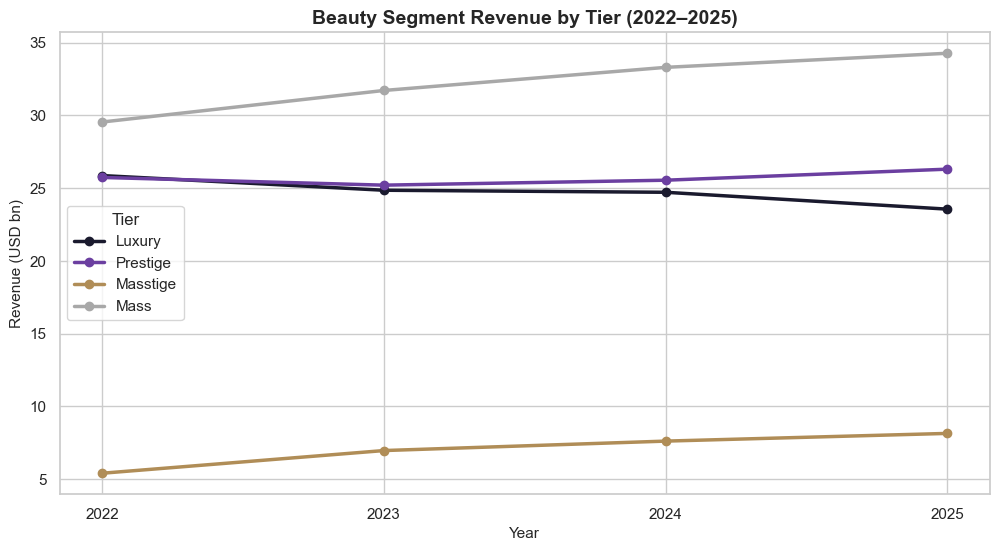

In [ ]:
# ── Chart 1: Revenue by Tier 2022–2025 ────────────────────
fig, ax = plt.subplots()

for tier in TIER_ORDER:
    group = df[df["Tier"] == tier]
    ax.plot(group["Year"], group["Revenue_USD_bn"],
            marker="o",
            label=tier,
            color=TIER_COLOURS[tier],
            linewidth=2.5)

ax.set_title("Beauty Segment Revenue by Tier (2022–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue (USD bn)")
ax.set_xticks([2022, 2023, 2024, 2025])
ax.legend(title="Tier")

save_chart(fig, "01_revenue_by_tier.png")
plt.show()

Saved: outputs\charts\01_growth_rate_by_tier.png


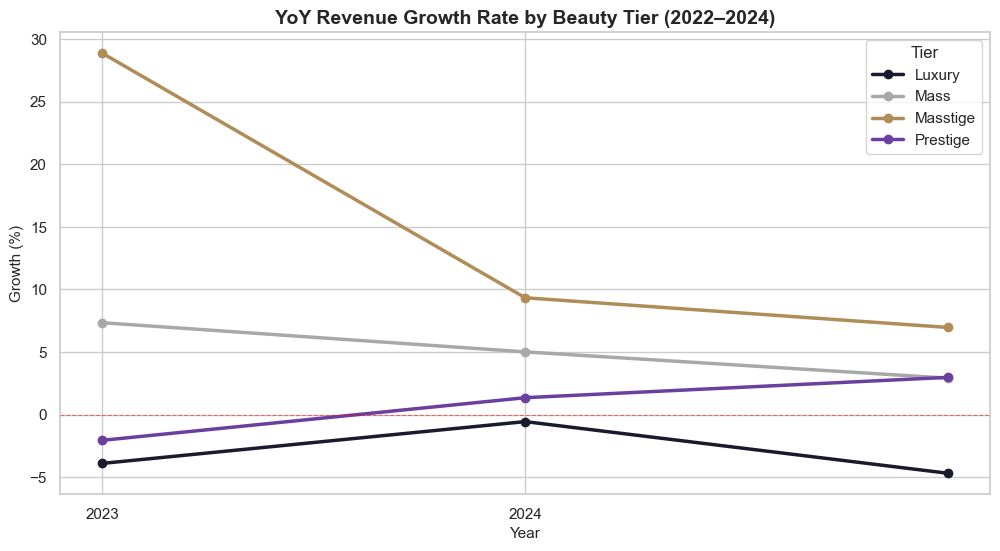

In [ ]:
# ── Chart 2: Growth Rate % by Tier ────────────────────────
df["Growth_pct"] = df.groupby("Tier")["Revenue_USD_bn"].pct_change() * 100

df_growth = df.dropna(subset=["Growth_pct"])

fig, ax = plt.subplots()

for tier, group in df_growth.groupby("Tier"):
    ax.plot(group["Year"], group["Growth_pct"],
            marker="o",
            label=tier,
            color=TIER_COLOURS[tier],
            linewidth=2.5)

ax.axhline(0, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("YoY Revenue Growth Rate by Beauty Tier (2022–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Growth (%)")
ax.set_xticks([2023, 2024])
ax.legend(title="Tier")

save_chart(fig, "01_growth_rate_by_tier.png")
plt.show()

## Key Observations

**Chart 1 — Revenue by Tier:**
- Mass largest in absolute terms (~$30–34bn), growing but decelerating
- Luxury and Prestige near-parity at ~$25bn in 2022, diverge thereafter
- Luxury contracts every year; Prestige dips in 2023 then recovers
- Masstige smallest but only tier with uninterrupted growth across all 4 years

**Chart 2 — Growth Rate:**
- Luxury: only tier in sustained decline (-3.9%, -0.6%, -4.7%)
- Prestige: -2.1% in 2023, recovers to +1.3% / +3.0% in 2024–25
- Mass: decelerates each year (7.3% → 5.0% → 2.9%)
- Masstige: strongest relative growth, +28.9% in 2023 (note: low base effect), 
  moderating to +9.3% / +7.0% in 2024–25

**Preliminary conclusion:** Masstige is the only tier with consistent positive 
growth throughout 2022–2025. Luxury contracts; Mass decelerates; Prestige 
recovers unevenly. Hypothesis directionally supported — to be tested further 
in Notebooks 03 and 04.